In [1]:
!pip install librosa numpy matplotlib soundfile scikit-learn imbalanced-learn tqdm
!mkdir visuals

A subdirectory or file visuals already exists.


🔬 Extracting features...


  0%|          | 0/8016 [00:00<?, ?it/s]C:\Users\user\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,
100%|██████████| 8016/8016 [1:27:28<00:00,  1.53it/s]


🖼️ Visualizing features for first 5 samples...


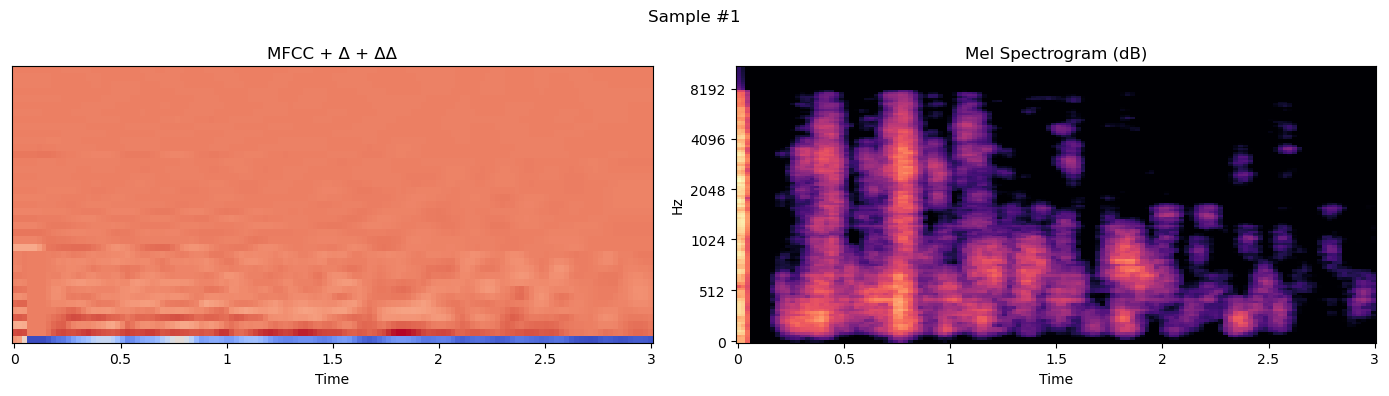

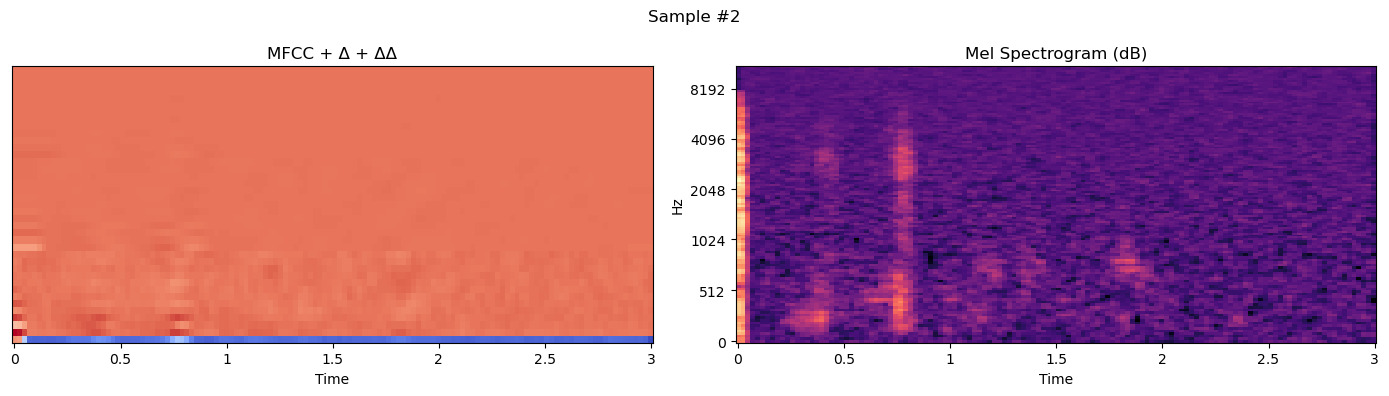

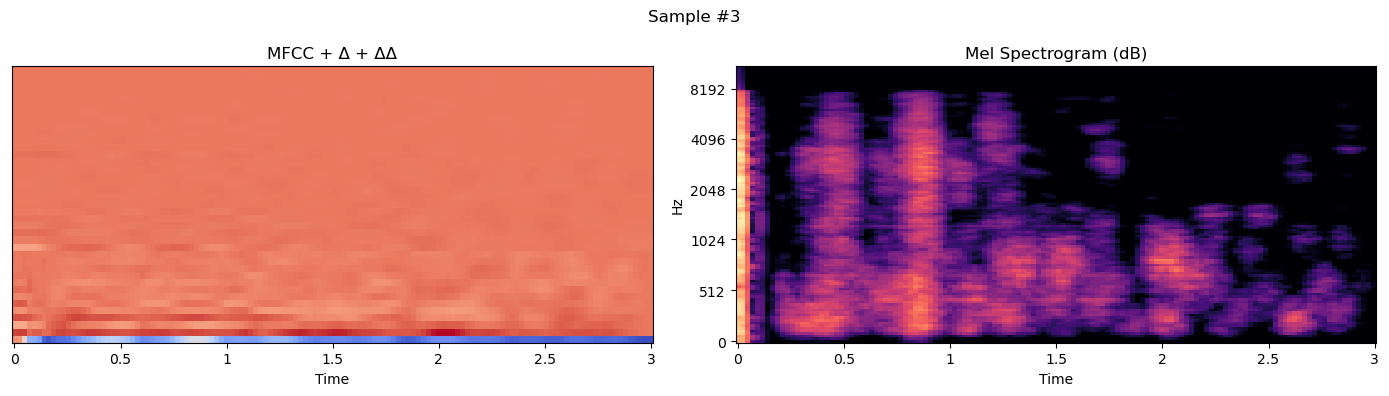

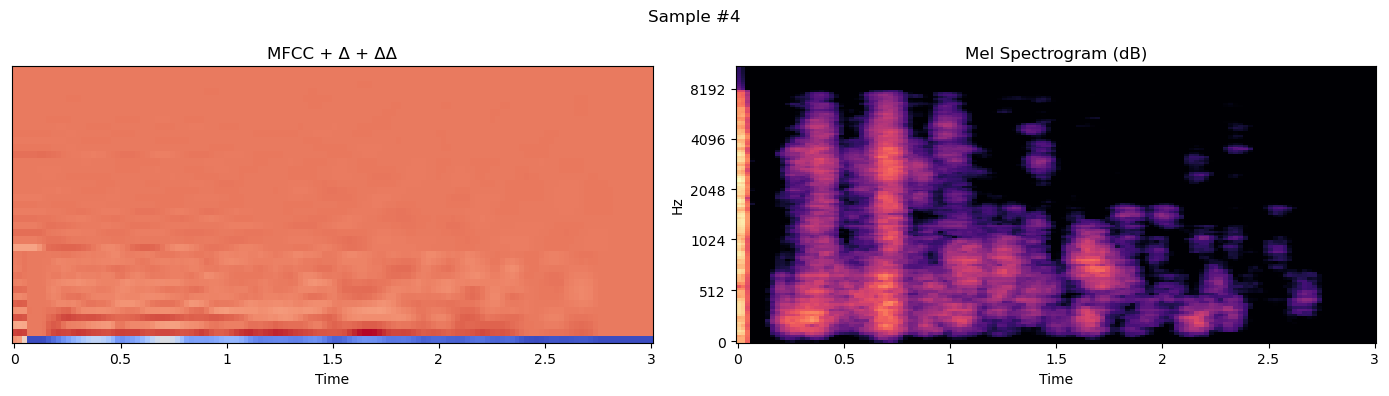

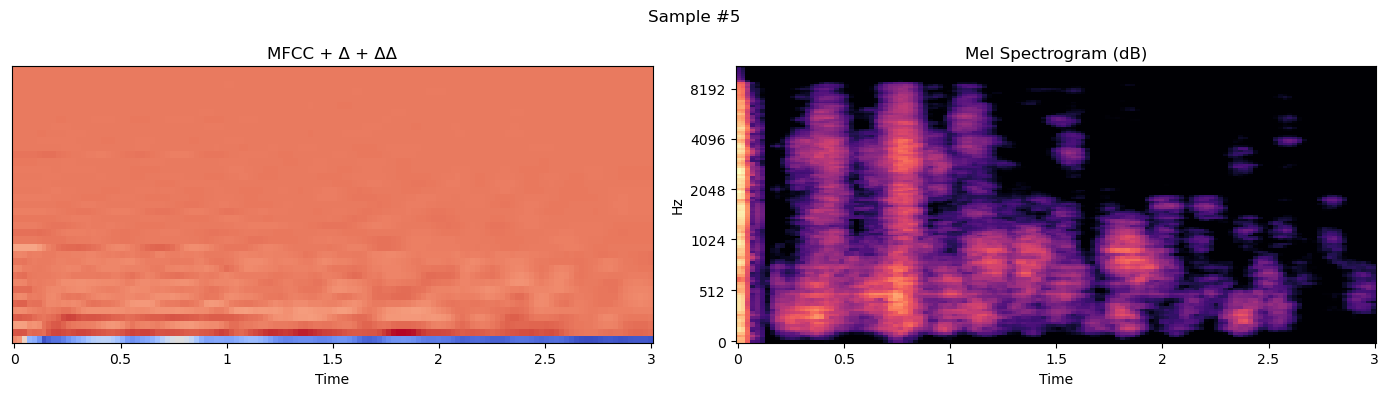

✅ Class distribution: {0: 3176, 1: 3176, 2: 3176, 3: 3176, 4: 3176}
✅ Saved: X_hybrid_balanced.npy, y_hybrid_balanced.npy


In [2]:
# ✅ HYBRID FEATURE EXTRACTION & BALANCING
import librosa, librosa.display
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import librosa.display
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from tqdm import tqdm


# ✅ 2. Load cleaned data
SAMPLE_RATE = 22050
X_clean = np.load("X_clean3.npy", mmap_mode='r')
y_clean = np.load("y_clean3.npy")

# ✅ 3. Prepare feature extraction directory
os.makedirs("newvisuals", exist_ok=True)


def extract_features(signal):
    mfcc = librosa.feature.mfcc(y=signal, sr=SAMPLE_RATE, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(delta)
    mfcc_combined = np.vstack([mfcc, delta, delta2])  # (39, T)
    mel = librosa.feature.melspectrogram(y=signal, sr=SAMPLE_RATE)
    zcr = librosa.feature.zero_crossing_rate(y=signal)
    rms = librosa.feature.rms(y=signal)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(signal), sr=SAMPLE_RATE)
    chroma = librosa.feature.chroma_stft(y=signal, sr=SAMPLE_RATE)

    min_T = min(mfcc.shape[1], delta.shape[1], mel.shape[1], zcr.shape[1], rms.shape[1], tonnetz.shape[1], chroma.shape[1])
    features = np.vstack([
        mfcc[:, :min_T],
        delta[:, :min_T],
        delta2[:, :min_T],
        mel[:, :min_T],
        zcr[:, :min_T],
        rms[:, :min_T],
        tonnetz[:, :min_T],
        chroma[:, :min_T]
    ])
    return StandardScaler().fit_transform(features)

print("🔬 Extracting features...")
X_feat = [extract_features(x) for x in tqdm(X_clean)]
# ✅ Visualize first few feature maps (MFCC & Mel)
print("🖼️ Visualizing features for first 5 samples...")

for i in range(5):
    signal = X_clean[i]
    
    # Extract individual features for display only
    mfcc = librosa.feature.mfcc(y=signal, sr=SAMPLE_RATE, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(delta)
    mel = librosa.feature.melspectrogram(y=signal, sr=SAMPLE_RATE)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    fig, axs = plt.subplots(1, 2, figsize=(14, 4))

    axs[0].set_title("MFCC + Δ + ΔΔ")
    mfcc_stack = np.vstack([mfcc, delta, delta2])
    librosa.display.specshow(mfcc_stack, sr=SAMPLE_RATE, x_axis='time', ax=axs[0])

    axs[1].set_title("Mel Spectrogram (dB)")
    librosa.display.specshow(mel_db, sr=SAMPLE_RATE, x_axis='time', y_axis='mel', ax=axs[1])

    plt.suptitle(f"Sample #{i+1}")
    plt.tight_layout()
    plt.show()

    # Save figures (optional)
    fig.savefig(f"newvisuals/features_sample_{i+1}.png")
    plt.close()


# Pad features
max_len = max(f.shape[1] for f in X_feat)
X_pad = [np.pad(f, ((0, 0), (0, max_len - f.shape[1])), mode='constant') for f in X_feat]
X_feat_arr = np.array(X_pad)

# Reshape for balancing
X_flat = X_feat_arr.reshape((X_feat_arr.shape[0], -1))
ros = RandomOverSampler()
X_resampled, y_resampled = ros.fit_resample(X_flat, y_clean)

# Reshape back
X_final = X_resampled.reshape((-1, X_feat_arr.shape[1], X_feat_arr.shape[2]))
np.save("X_hybrid_balanced.npy", X_final)
np.save("y_hybrid_balanced.npy", y_resampled)

# ✅ Distribution Check
unique, counts = np.unique(y_resampled, return_counts=True)
print("✅ Class distribution:", dict(zip(unique, counts)))
print("✅ Saved: X_hybrid_balanced.npy, y_hybrid_balanced.npy")


In [3]:
import numpy as np

# Load resampled labels
y_resampled = np.load("y_hybrid_balanced.npy")

# Count samples per class
unique, counts = np.unique(y_resampled, return_counts=True)
class_dist = dict(zip(unique, counts))

print("✅ Final Class Distribution:", class_dist)


✅ Final Class Distribution: {0: 3176, 1: 3176, 2: 3176, 3: 3176, 4: 3176}


✅ Final Class Distribution:
belly pain: 3176
burping: 3176
discomfort: 3176
hungry: 3176
tired: 3176


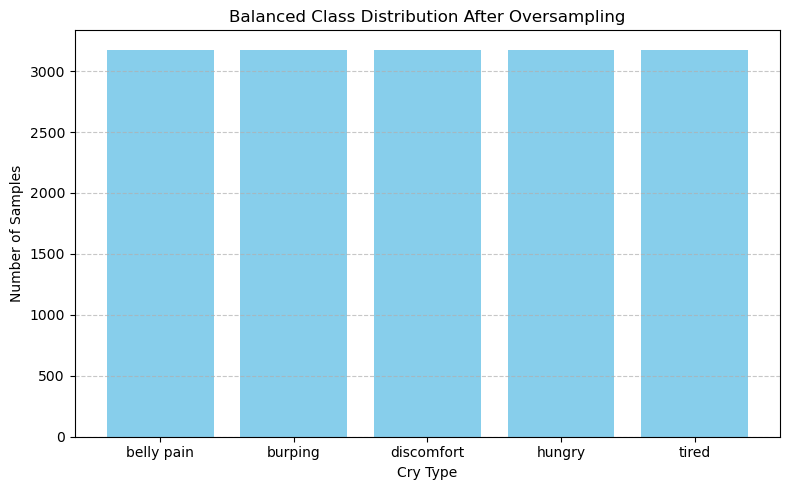

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load balanced labels
y_balanced = np.load("y_hybrid_balanced.npy")

# Class name mapping
class_names = ['belly pain', 'burping', 'discomfort', 'hungry', 'tired']

# Count occurrences
unique, counts = np.unique(y_balanced, return_counts=True)
class_dist = dict(zip(unique, counts))

# Print exact counts
print("✅ Final Class Distribution:")
for i, count in class_dist.items():
    print(f"{class_names[i]}: {count}")

# Plot
plt.figure(figsize=(8, 5))
plt.bar([class_names[i] for i in unique], counts, color='skyblue')
plt.title("Balanced Class Distribution After Oversampling")
plt.xlabel("Cry Type")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
